# **PART III — NLP (Spam vs Ham Classification)**

**1. IMPORT LIBRARIES**

In [ ]:
!pip install contractions gensim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import contractions
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout

import gensim.downloader as api

In [ ]:
!pip install contractions

**2. DOWNLOAD NLTK RESOURCES**

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


**3. LOAD DATASET (Google Drive)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/AI&ML/spamvsham.csv', encoding='latin-1')

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


**4. LABEL ENCODING**

In [ ]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

**5. Data Visualization**

**Class Distribution**

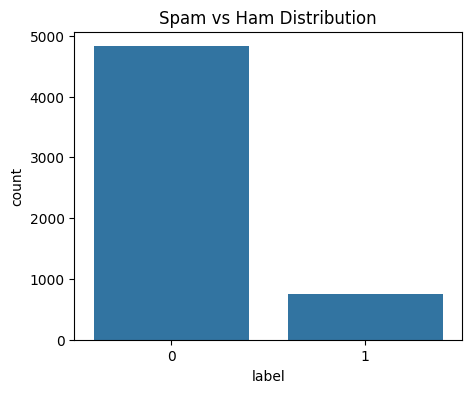

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x=df['label'])
plt.title("Spam vs Ham Distribution")
plt.show()

**Word Frequency**

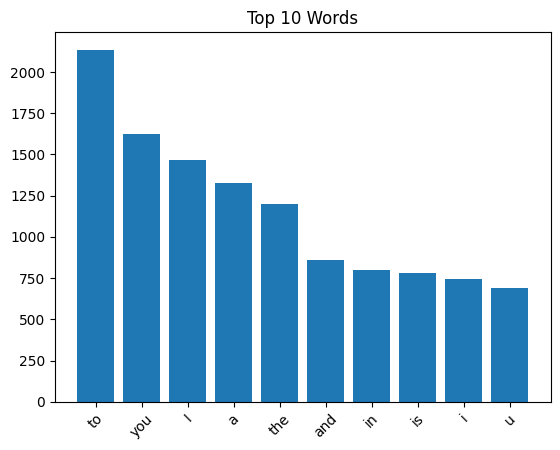

In [ ]:
from collections import Counter

all_words = " ".join(df['message']).split()
word_freq = Counter(all_words).most_common(10)

words, counts = zip(*word_freq)

plt.bar(words, counts)
plt.title("Top 10 Words")
plt.xticks(rotation=45)
plt.show()

**6. TEXT CLEANING**

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = contractions.fix(text)

    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(w)
        for w in words
        if w not in stop_words and len(w) > 1
    ]

    return " ".join(words)

df['clean_text'] = df['message'].apply(clean_text)

**7. TRAIN-TEST SPLIT**

In [ ]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = X_train.tolist()
X_test = X_test.tolist()

**8. Tokenization + Padding**

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

vocab_size = len(tokenizer.word_index) + 1

**9. VOCAB SIZE**

In [ ]:
vocab_size = len(tokenizer.word_index) + 1
print(vocab_size)

6207


In [ ]:
print(df['label'].value_counts())

label
0    4825
1     747
Name: count, dtype: int64


**Class weight**

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.5773316062176166), 1: np.float64(3.7328308207705194)}


# **10.MODEL**

**11.RNN MODEL**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128),

    SimpleRNN(64),

    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_rnn.build(input_shape=(None, max_len))
model_rnn.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_20 (Embedding)        │ (None, 100, 128)       │       794,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_10 (SimpleRNN)       │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 806,913 (3.08 MB)

 Trainable params: 806,913 (3.08 MB)

 Non-trainable params: 0 (0.00 B)

**12.LSTM MODEL**

In [ ]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128),

    LSTM(64, return_sequences=False),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_lstm.build(input_shape=(None, max_len))
model_lstm.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_21 (Embedding)        │ (None, 100, 128)       │       794,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 846,017 (3.23 MB)

 Trainable params: 846,017 (3.23 MB)

 Non-trainable params: 0 (0.00 B)

**13.TRAIN MODELS**

**RNN**

In [ ]:
history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    epochs=10,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.5868 - loss: 0.7249 - val_accuracy: 0.6827 - val_loss: 0.6534
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7088 - loss: 0.6095 - val_accuracy: 0.6603 - val_loss: 0.6257
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8317 - loss: 0.4482 - val_accuracy: 0.7478 - val_loss: 0.5858
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8892 - loss: 0.3378 - val_accuracy: 0.7724 - val_loss: 0.5629
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9386 - loss: 0.2304 - val_accuracy: 0.8408 - val_loss: 0.4496
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9658 - loss: 0.1328 - val_accuracy: 0.8756 - val_loss: 0.3976
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9529 - loss: 0.1548 - val_accuracy: 0.8643 - val_loss: 0.4291
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9804 - loss: 0.0930 - val_accu

**LSTM**

In [ ]:
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=10,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8491 - loss: 0.3346 - val_accuracy: 0.9776 - val_loss: 0.0767
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9854 - loss: 0.0689 - val_accuracy: 0.9675 - val_loss: 0.1036
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9938 - loss: 0.0264 - val_accuracy: 0.9832 - val_loss: 0.0704
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9969 - loss: 0.0152 - val_accuracy: 0.9787 - val_loss: 0.0798
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9978 - loss: 0.0068 - val_accuracy: 0.9809 - val_loss: 0.0808
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9983 - loss: 0.0074 - val_accuracy: 0.9832 - val_loss: 0.0875
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9989 - loss: 0.0071 - val_accuracy: 0.9731 - val_loss: 0.1235
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9989 - loss: 0.0019 - val_accu

In [ ]:
preds = (model_lstm.predict(X_test_pad) > 0.35).astype(int)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


**14.VISUALIZATION**

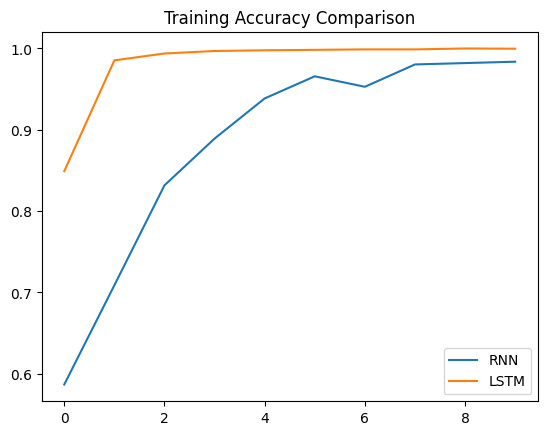

In [ ]:
plt.plot(history_rnn.history['accuracy'], label='RNN')
plt.plot(history_lstm.history['accuracy'], label='LSTM')
plt.title("Training Accuracy Comparison")
plt.legend()
plt.show()

**15.EVALUATION**

In [ ]:
def evaluate(model, name):
    preds = (model.predict(X_test_pad) > 0.5).astype("int32")
    print("\n", name)
    print(classification_report(y_test, preds))

evaluate(model_rnn, "RNN")
evaluate(model_lstm, "LSTM")

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

 RNN
              precision    recall  f1-score   support

           0       0.96      0.87      0.91       965
           1       0.47      0.76      0.58       150

    accuracy                           0.85      1115
   macro avg       0.72      0.81      0.75      1115
weighted avg       0.89      0.85      0.87      1115

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

 LSTM
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.89      0.93       150

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



# **WORD2VEC SECTION**

**16.Load Word2Vec**

In [ ]:
embedding_model = api.load("glove-wiki-gigaword-50")
embedding_dim = 50

**17.Embedding Matrix**

In [ ]:
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]

**18. LSTM + WORD2VEC MODEL**

In [ ]:
model_w2v = Sequential([
    Embedding(
        vocab_size,
        embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False
    ),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model_w2v.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


**19.TRAIN WORD2VEC MODEL**

In [ ]:
model_w2v.fit(X_train_pad, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8892 - loss: 0.3199 - val_accuracy: 0.9327 - val_loss: 0.1732
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9487 - loss: 0.1490 - val_accuracy: 0.9529 - val_loss: 0.1480
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9576 - loss: 0.1321 - val_accuracy: 0.9585 - val_loss: 0.1254
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9473 - loss: 0.1269 - val_accuracy: 0.9552 - val_loss: 0.1458
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9576 - loss: 0.1367 - val_accuracy: 0.9182 - val_loss: 0.1698
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9610 - loss: 0.1249 - val_accuracy: 0.9608 - val_loss: 0.1635
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9613 - loss: 0.1249 - val_accuracy: 0.9518 - val_loss: 0.1345
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9638 - loss: 0.1125 - val_accuracy:

**22. WORD2VEC SUMMARY**

In [ ]:
model_w2v.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_23 (Embedding)        │ (None, 100, 50)        │       310,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 398,867 (1.52 MB)

 Trainable params: 29,505 (115.25 KB)

 Non-trainable params: 310,350 (1.18 MB)

 Optimizer params: 59,012 (230.52 KB)

**23. FINAL EVALUATION**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(model, X_test, y_test, name):

    probs = model.predict(X_test)
    preds = (probs > 0.5).astype(int).flatten()

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=1)
    rec = recall_score(y_test, preds, zero_division=1)
    f1 = f1_score(y_test, preds, zero_division=1)

    print("\n", name)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    print("\nConfusion Matrix:\n", cm)

    return acc, prec, rec, f1

In [ ]:
rnn_acc = evaluate_model(model_rnn, X_test_pad, y_test, "RNN")
lstm_acc = evaluate_model(model_lstm, X_test_pad, y_test, "LSTM")
w2v_acc = evaluate_model(model_w2v, X_test_pad, y_test, "LSTM + Word2Vec")

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

 RNN
Accuracy: 0.8538116591928251
Precision: 0.4730290456431535
Recall: 0.76
F1 Score: 0.5831202046035806

Confusion Matrix:
 [[838 127]
 [ 36 114]]
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

 LSTM
Accuracy: 0.9829596412556054
Precision: 0.9851851851851852
Recall: 0.8866666666666667
F1 Score: 0.9333333333333333

Confusion Matrix:
 [[963   2]
 [ 17 133]]
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

 LSTM + Word2Vec
Accuracy: 0.968609865470852
Precision: 0.891156462585034
Recall: 0.8733333333333333
F1 Score: 0.8821548821548821

Confusion Matrix:
 [[949  16]
 [ 19 131]]


In [ ]:
results = pd.DataFrame({
    "Model": ["RNN", "LSTM", "Word2Vec LSTM"],
    "Accuracy": [rnn_acc[0], lstm_acc[0], w2v_acc[0]],
    "Precision": [rnn_acc[1], lstm_acc[1], w2v_acc[1]],
    "Recall": [rnn_acc[2], lstm_acc[2], w2v_acc[2]],
    "F1 Score": [rnn_acc[3], lstm_acc[3], w2v_acc[3]]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,RNN,0.853812,0.473029,0.760000,0.583120
1,LSTM,0.982960,0.985185,0.886667,0.933333
2,Word2Vec LSTM,0.968610,0.891156,0.873333,0.882155


# **CONFUSION MATRIX**

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


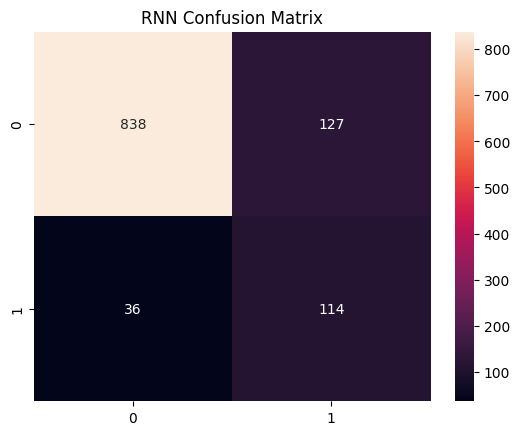

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


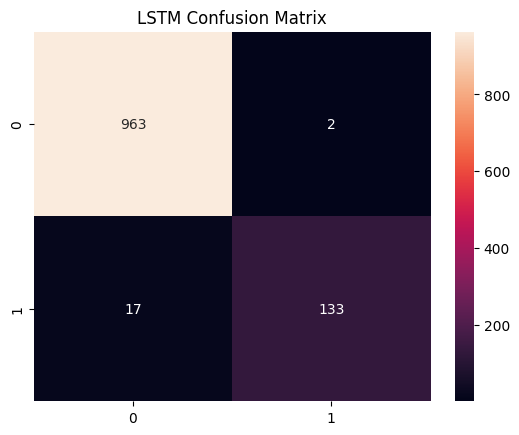

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


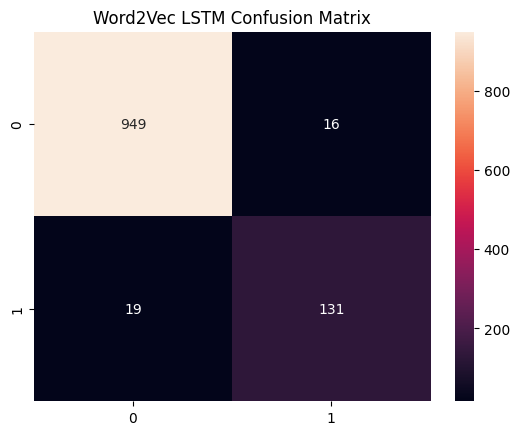

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cm(model, name):
    preds = (model.predict(X_test_pad) > 0.5).astype(int).flatten()
    cm = confusion_matrix(y_test, preds)

    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(name + " Confusion Matrix")
    plt.show()

plot_cm(model_rnn, "RNN")
plot_cm(model_lstm, "LSTM")
plot_cm(model_w2v, "Word2Vec LSTM")

# **ACCURACY COMPARISON PLOT**

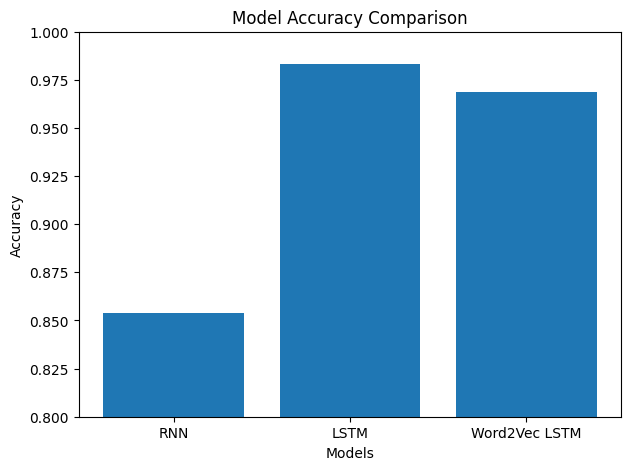

In [ ]:
import matplotlib.pyplot as plt

models = ["RNN", "LSTM", "Word2Vec LSTM"]
accuracy = [0.8538, 0.9830, 0.9686]

plt.figure(figsize=(7,5))
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0.8, 1.0)  # zoom for better visibility

plt.show()